# 🥐 스프린트 미션 16: 베이커리 구매 데이터 EDA

에든버러의 한 베이커리에서 2016-10-30 ~ 2017-04-09까지의 고객 구매 데이터를 분석합니다. 

- **목표:** 고객의 구매 패턴을 파악하고, 상품 간 상호작용 및 흥미로운 패턴을 발견하여 매출 증대와 고객 만족도 향상 전략을 도출합니다.
- **분석 흐름:**
    1. 데이터셋 및 컬럼 소개
    2. 데이터 기본 탐색 (결측치, 타입, 기초 통계)
    3. 시각화 기반 EDA (시간/요일/상품별 등)
    4. 인사이트 및 마케팅 전략 제안

---

## 1. 데이터셋 및 컬럼 소개

- **데이터 파일:** `bakery_sales_revised.csv`
- **컬럼 설명:**
    - `Transaction`: 거래 ID
    - `Item`: 구매한 제품명
    - `date_time`: 거래 날짜 및 시각
    - `period_day`: 아침/오후/저녁/밤 중 언제 구매했는지
    - `weekday_weekend`: 주중/주말 여부

---

## 2. 데이터 기초 탐색
- 결측치, 데이터 타입, 기초 통계량을 확인합니다.
- 데이터의 전반적인 구조를 파악합니다.


In [1]:
# 라이브러리 불러오기 및 데이터 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# 한글 폰트 설정 (Windows 환경)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
df = pd.read_csv('./data/bakery_sales_revised.csv')

df.head()

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,10/30/2016 9:58,morning,weekend
1,2,Scandinavian,10/30/2016 10:05,morning,weekend
2,2,Scandinavian,10/30/2016 10:05,morning,weekend
3,3,Hot chocolate,10/30/2016 10:07,morning,weekend
4,3,Jam,10/30/2016 10:07,morning,weekend


In [2]:
# 데이터프레임 기본 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


In [3]:
# 데이터프레임 기초 통계량 확인
df.describe(include='all')

,Transaction,Item,date_time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507
unique,NaN,94,9182,4,2
top,NaN,Coffee,2/5/2017 11:58,afternoon,weekday
freq,NaN,5471,12,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN


In [4]:
# 1. 결측치 개수 및 비율
missing_count = df.isnull().sum()
missing_ratio = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({'결측치 개수': missing_count, '결측치 비율(%)': missing_ratio})
display(missing_df)

,결측치 개수,결측치 비율(%)
Transaction,0,0.0
Item,0,0.0
date_time,0,0.0
period_day,0,0.0
weekday_weekend,0,0.0


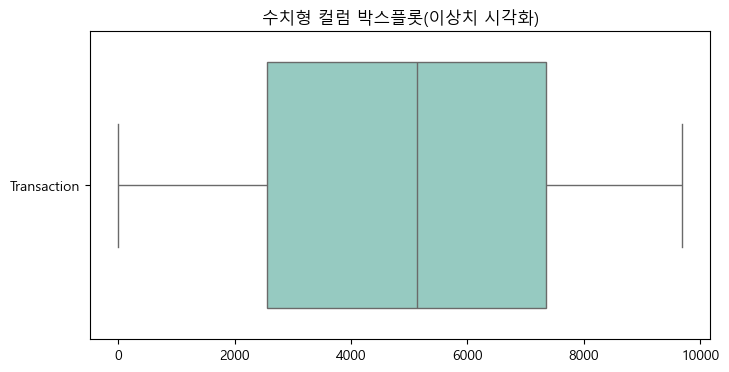

Transaction 이상치 개수: 0개, 비율: 0.00%


In [5]:
# 2. 이상치 탐색 (수치형 컬럼)
num_cols = df.select_dtypes(include=[np.number]).columns
if len(num_cols) > 0:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df[num_cols], orient='h', palette='Set3')
    plt.title('수치형 컬럼 박스플롯(이상치 시각화)')
    plt.show()
    
    # 이상치 비율 계산 (IQR 기준)
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
        ratio = outliers / len(df) * 100
        print(f"{col} 이상치 개수: {outliers}개, 비율: {ratio:.2f}%")

전체 중복 행 개수: 1620개, 비율: 7.90%
주요 컬럼 기준 중복 행 개수: 1620개, 비율: 7.90%


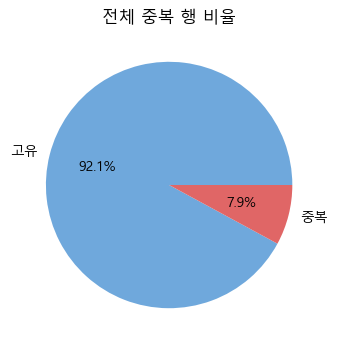

,Transaction,Item,date_time,period_day,weekday_weekend
1,2,Scandinavian,10/30/2016 10:05,morning,weekend
2,2,Scandinavian,10/30/2016 10:05,morning,weekend
23,11,Bread,10/30/2016 10:27,morning,weekend
25,11,Bread,10/30/2016 10:27,morning,weekend
48,21,Coffee,10/30/2016 10:49,morning,weekend


In [6]:
# 3. 중복치 탐색
# 전체 중복 행
all_dup_count = df.duplicated().sum()
all_dup_ratio = all_dup_count / len(df) * 100
print(f"전체 중복 행 개수: {all_dup_count}개, 비율: {all_dup_ratio:.2f}%")

# 주요 컬럼 기준(거래ID+제품+날짜) 중복
key_dup_count = df.duplicated(subset=['Transaction','Item','date_time']).sum()
key_dup_ratio = key_dup_count / len(df) * 100
print(f"주요 컬럼 기준 중복 행 개수: {key_dup_count}개, 비율: {key_dup_ratio:.2f}%")

# 중복 행 시각화
labels = ['고유', '중복']
values = [len(df)-all_dup_count, all_dup_count]
plt.figure(figsize=(4,4))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=['#6fa8dc','#e06666'])
plt.title('전체 중복 행 비율')
plt.show()

# 중복 행 예시 출력
display(df[df.duplicated(keep=False)].head())

In [11]:
# date_time을 datetime 타입으로 변환
df['date_time'] = pd.to_datetime(df['date_time'])

# 날짜와 시간 컬럼 분리
df['date'] = df['date_time'].dt.date
df['time'] = df['date_time'].dt.time

# 결과 확인
df[['date_time', 'date', 'time']].head()

,date_time,date,time
0,2016-10-30 09:58:00,2016-10-30,09:58:00
1,2016-10-30 10:05:00,2016-10-30,10:05:00
2,2016-10-30 10:05:00,2016-10-30,10:05:00
3,2016-10-30 10:07:00,2016-10-30,10:07:00
4,2016-10-30 10:07:00,2016-10-30,10:07:00


In [37]:
df.describe(include='all')

,Transaction,Item,date_time,period_day,weekday_weekend,date,time,hour,weekday_eng,weekday_kr
count,20507.000000,20507,20507,20507,20507,20507,20507,20507.000000,20507,20507
unique,NaN,94,NaN,4,2,159,687,NaN,7,7
top,NaN,Coffee,NaN,afternoon,weekday,2017-02-04,11:06:00,NaN,Saturday,토요일
freq,NaN,5471,NaN,11569,12807,292,78,NaN,4605,4605
mean,4976.202370,NaN,2017-01-18 01:31:08.552201728,NaN,NaN,NaN,NaN,12.270883,NaN,NaN
min,1.000000,NaN,2016-10-30 09:58:00,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,2552.000000,NaN,2016-12-03 14:28:00,NaN,NaN,NaN,NaN,10.000000,NaN,NaN
50%,5137.000000,NaN,2017-01-22 11:18:00,NaN,NaN,NaN,NaN,12.000000,NaN,NaN
75%,7357.000000,NaN,2017-02-28 16:00:00,NaN,NaN,NaN,NaN,14.000000,NaN,NaN
max,9684.000000,NaN,2017-04-09 15:04:00,NaN,NaN,NaN,NaN,23.000000,NaN,NaN



---

## 3. 주요 EDA 분석
- 시간대, 요일, 제품별로 다양한 시각화와 분석을 진행합니다.
- 아래 셀부터 하나씩 실행하며 인사이트를 도출해보세요!


C:\Users\ypsoo\AppData\Local\Temp\ipykernel_34340\392271379.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='period_day', order=['morning','afternoon','evening','night'], palette='pastel')


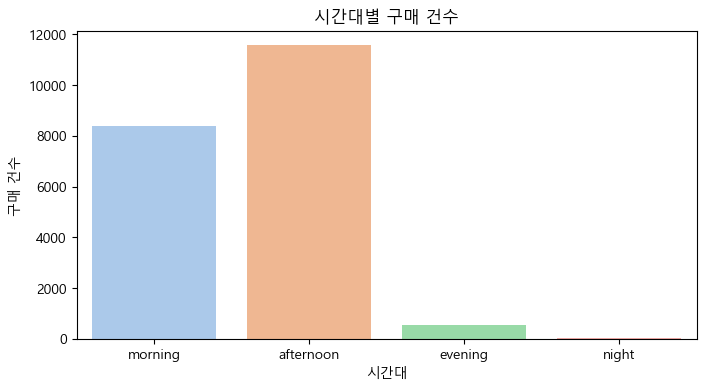

In [ ]:
# 시간대별 구매 건수 시각화

plt.figure(figsize=(8,4))
sns.countplot(data=df, x='period_day', order=['morning','afternoon','evening','night'], palette='pastel')
plt.title('시간대별 구매 건수')
plt.xlabel('시간대')
plt.ylabel('구매 건수')
plt.show()

C:\Users\ypsoo\AppData\Local\Temp\ipykernel_34340\603630449.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hour', palette='Blues')


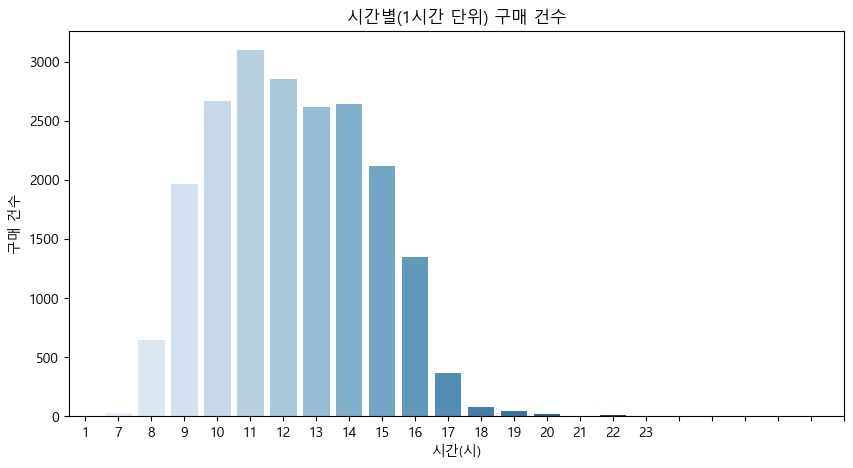

In [31]:
# 시간별(1시간 단위) 구매 건수 집계 및 시각화
df['hour'] = df['date_time'].dt.hour

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='hour', palette='Blues')
plt.title('시간별(1시간 단위) 구매 건수')
plt.xlabel('시간(시)')
plt.ylabel('구매 건수')
plt.xticks(range(0, 24))
plt.show();

C:\Users\ypsoo\AppData\Local\Temp\ipykernel_34340\1383715854.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='weekday_weekend', palette='Set2')


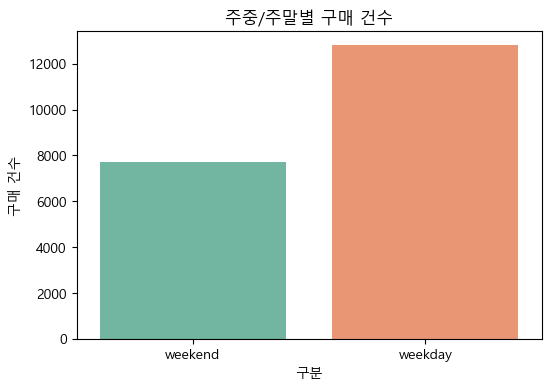

In [10]:
# 주중/주말별 구매 건수 시각화
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='weekday_weekend', palette='Set2')
plt.title('주중/주말별 구매 건수')
plt.xlabel('구분')
plt.ylabel('구매 건수')
plt.show();

C:\Users\ypsoo\AppData\Local\Temp\ipykernel_34340\1742012889.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='weekday_kr', order=order_kr, palette='Spectral')


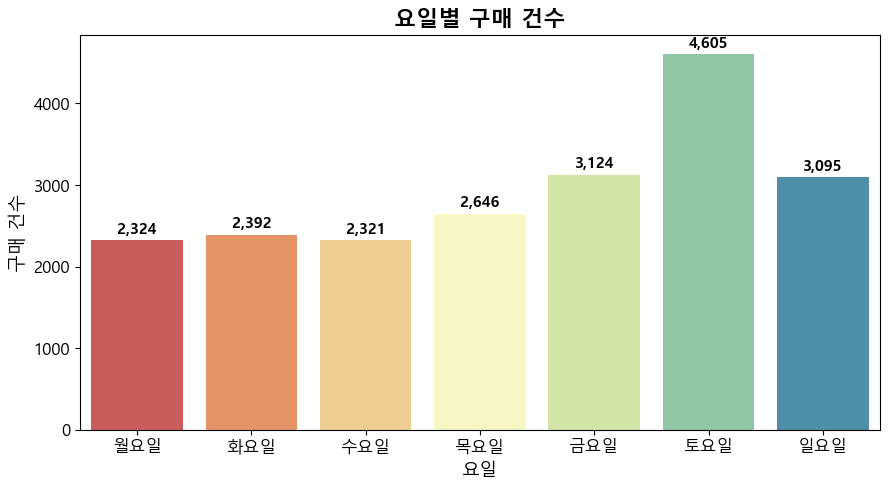

In [16]:
# 요일별 구매 건수 집계
weekday_map = {
    'Monday': '월요일', 'Tuesday': '화요일', 'Wednesday': '수요일',
    'Thursday': '목요일', 'Friday': '금요일', 'Saturday': '토요일', 'Sunday': '일요일'
}
df['weekday_eng'] = df['date_time'].dt.day_name()
df['weekday_kr'] = df['weekday_eng'].map(weekday_map)

# 요일별 순서 지정
order_kr = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']

plt.figure(figsize=(9,5))
sns.countplot(data=df, x='weekday_kr', order=order_kr, palette='Spectral')
plt.title('요일별 구매 건수', fontsize=16, fontweight='bold')
plt.xlabel('요일', fontsize=13)
plt.ylabel('구매 건수', fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
for i, count in enumerate(df['weekday_kr'].value_counts()[order_kr]):
    plt.text(i, count+30, f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\ypsoo\AppData\Local\Temp\ipykernel_34340\2254645556.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.values, y=top_items.index, palette='mako')


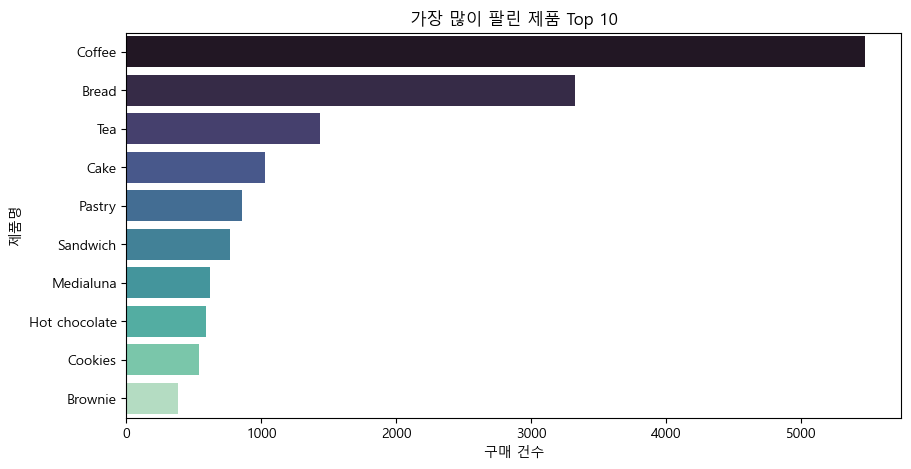

In [17]:
# 제품별 구매 Top 10
plt.figure(figsize=(10,5))
top_items = df['Item'].value_counts().head(10)
sns.barplot(x=top_items.values, y=top_items.index, palette='mako')
plt.title('가장 많이 팔린 제품 Top 10')
plt.xlabel('구매 건수')
plt.ylabel('제품명')
plt.show()

C:\Users\ypsoo\AppData\Local\Temp\ipykernel_34340\1309104769.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_items.index, x=top_items.values, palette='viridis')
C:\Users\ypsoo\AppData\Local\Temp\ipykernel_34340\1309104769.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_items.index, x=top_items.values, palette='viridis')
C:\Users\ypsoo\AppData\Local\Temp\ipykernel_34340\1309104769.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_items.index, x=top_items.values, palette='viridis')
C:\Users\ypsoo\AppData\Local\Temp\

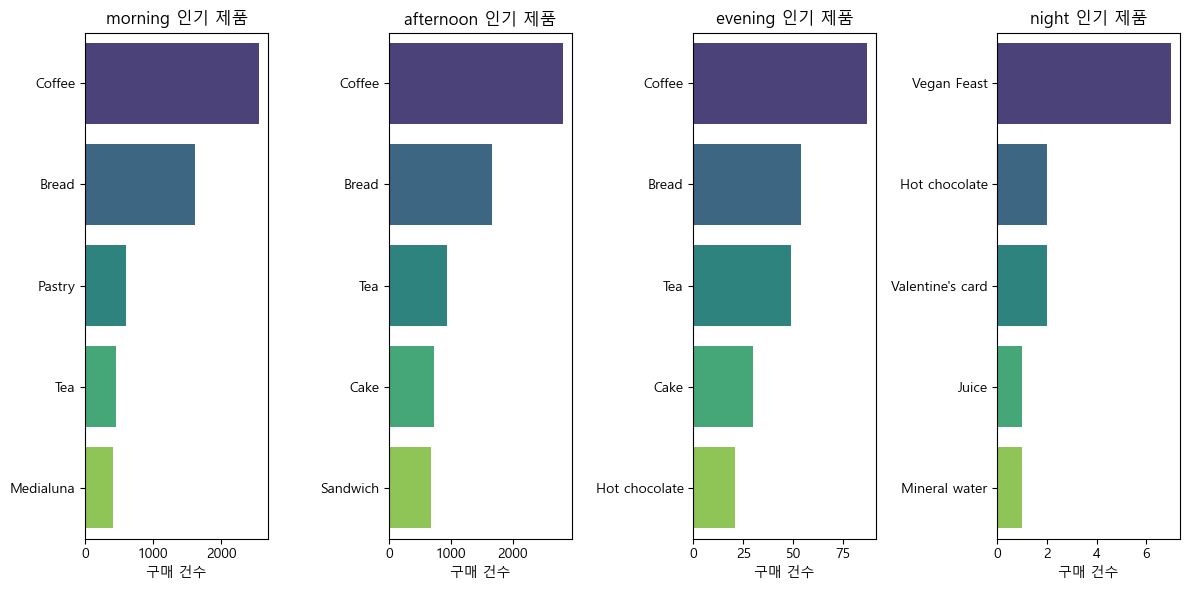

In [35]:
# 시간대별 인기 제품 Top 5
plt.figure(figsize=(12,6))
for i, period in enumerate(['morning','afternoon','evening','night']):
    plt.subplot(1,4,i+1)
    top_items = df[df['period_day']==period]['Item'].value_counts().head(5)
    sns.barplot(y=top_items.index, x=top_items.values, palette='viridis')
    plt.title(f'{period} 인기 제품')
    plt.xlabel('구매 건수')
    plt.ylabel('')
plt.tight_layout()
plt.show()

C:\Users\ypsoo\AppData\Local\Temp\ipykernel_34340\3781986546.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_items.index, x=top_items.values, palette='crest')
C:\Users\ypsoo\AppData\Local\Temp\ipykernel_34340\3781986546.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_items.index, x=top_items.values, palette='crest')


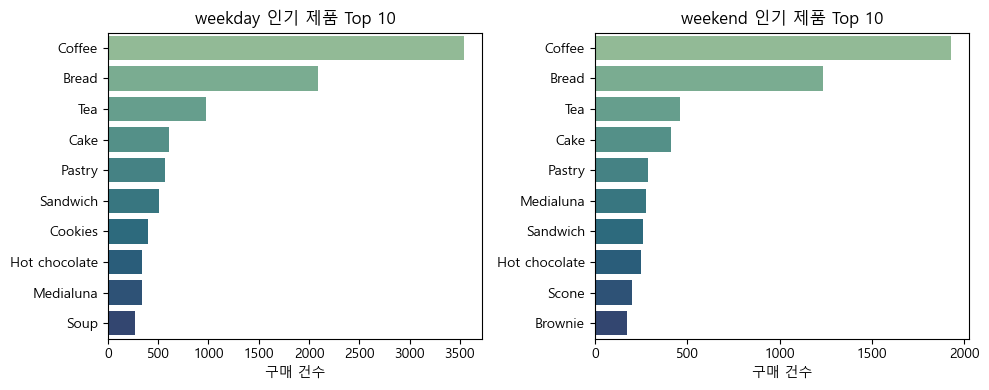

In [26]:
# 주중/주말별 인기 제품 Top 10 시각화
plt.figure(figsize=(10,4))
for i, daytype in enumerate(['weekday', 'weekend']):
    plt.subplot(1,2,i+1)
    top_items = df[df['weekday_weekend']==daytype]['Item'].value_counts().head(10)
    sns.barplot(y=top_items.index, x=top_items.values, palette='crest')
    plt.title(f'{daytype} 인기 제품 Top 10')
    plt.xlabel('구매 건수')
    plt.ylabel('')
plt.tight_layout()
plt.show()

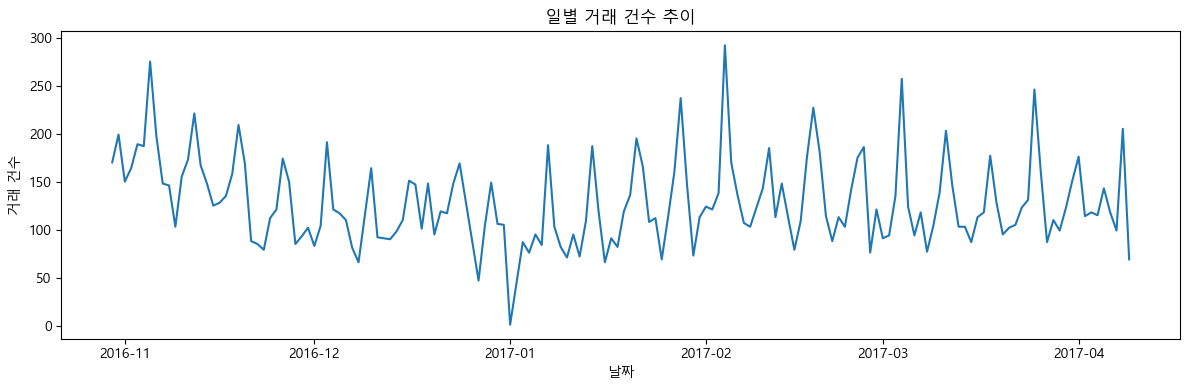

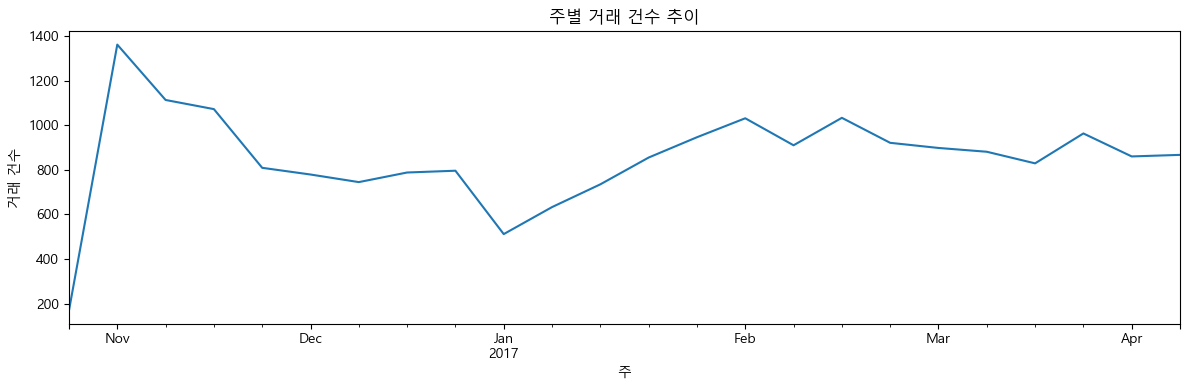

C:\Users\ypsoo\AppData\Local\Temp\ipykernel_34340\2265815013.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.groupby(pd.to_datetime(df['date'])).size().resample('M').sum()


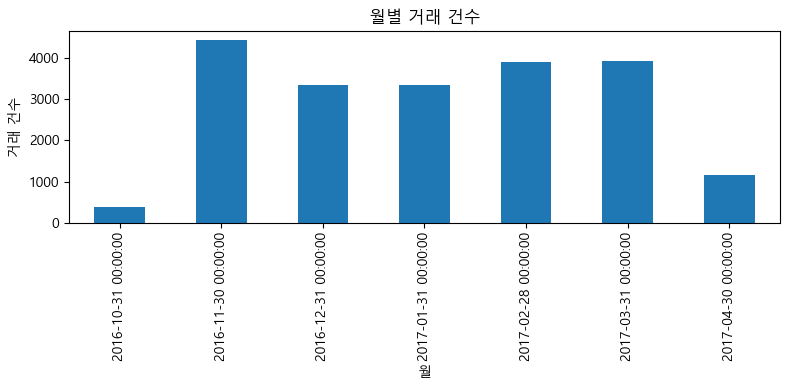

In [27]:
# [3] 시간 흐름에 따른 전체 매출 트렌드
# 일별 거래 건수 추이
plt.figure(figsize=(12,4))
daily = df.groupby('date').size()
daily.plot()
plt.title('일별 거래 건수 추이')
plt.xlabel('날짜')
plt.ylabel('거래 건수')
plt.tight_layout()
plt.show()

# 주별 거래 건수 추이
plt.figure(figsize=(12,4))
weekly = df.groupby(pd.to_datetime(df['date'])).size().resample('W').sum()
weekly.plot()
plt.title('주별 거래 건수 추이')
plt.xlabel('주')
plt.ylabel('거래 건수')
plt.tight_layout()
plt.show()

# 월별 거래 건수 추이
plt.figure(figsize=(8,4))
monthly = df.groupby(pd.to_datetime(df['date'])).size().resample('M').sum()
monthly.plot(kind='bar')
plt.title('월별 거래 건수')
plt.xlabel('월')
plt.ylabel('거래 건수')
plt.tight_layout()
plt.show()

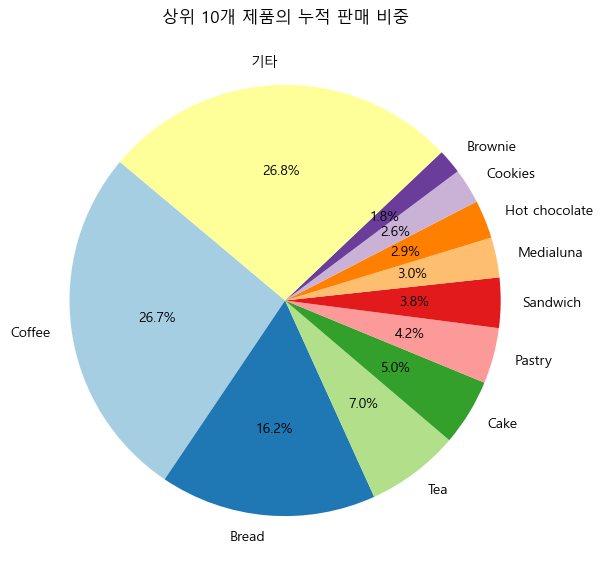

In [28]:
# [4] 상위 10개 제품의 누적 비중 파이차트
item_counts = df['Item'].value_counts()
top10 = item_counts.head(10)
others = item_counts[10:].sum()
labels = list(top10.index) + ['기타']
values = list(top10.values) + [others]
plt.figure(figsize=(7,7))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Paired', 11))
plt.title('상위 10개 제품의 누적 판매 비중')
plt.show()

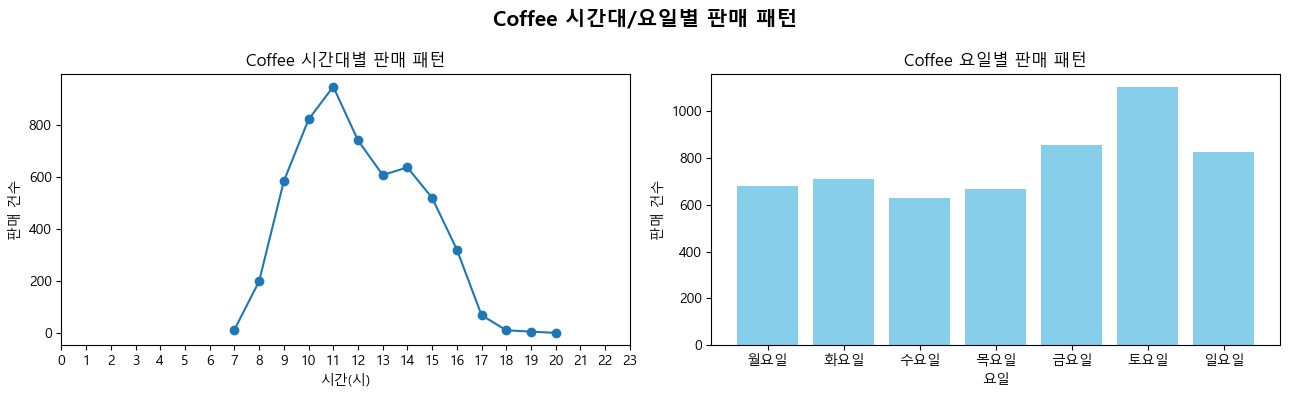

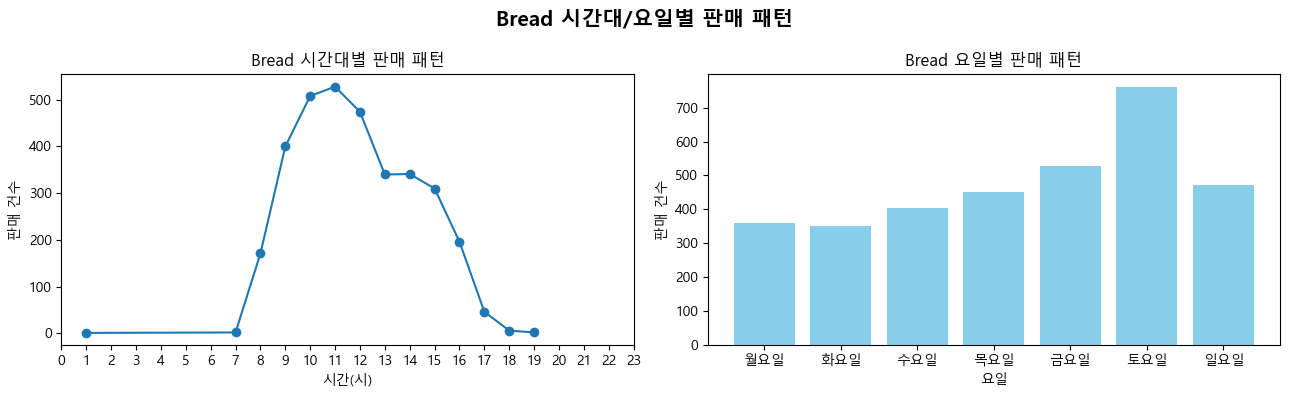

In [36]:
# [6] 특정 제품의 시간대/요일별 판매 패턴
# 예시: Coffee, Croissant
selected_items = ['Coffee', 'Bread']

for item in selected_items:
    fig, axes = plt.subplots(1, 2, figsize=(13,4))
    # 시간대별
    hour_counts = df[df['Item']==item]['hour'].value_counts().sort_index()
    axes[0].plot(hour_counts.index, hour_counts.values, marker='o')
    axes[0].set_title(f'{item} 시간대별 판매 패턴')
    axes[0].set_xlabel('시간(시)')
    axes[0].set_ylabel('판매 건수')
    axes[0].set_xticks(range(0,24))
    # 요일별
    weekday_counts = df[df['Item']==item]['weekday_kr'].value_counts().reindex(['월요일','화요일','수요일','목요일','금요일','토요일','일요일'])
    axes[1].bar(weekday_counts.index, weekday_counts.values, color='skyblue')
    axes[1].set_title(f'{item} 요일별 판매 패턴')
    axes[1].set_xlabel('요일')
    axes[1].set_ylabel('판매 건수')
    plt.suptitle(f'{item} 시간대/요일별 판매 패턴', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

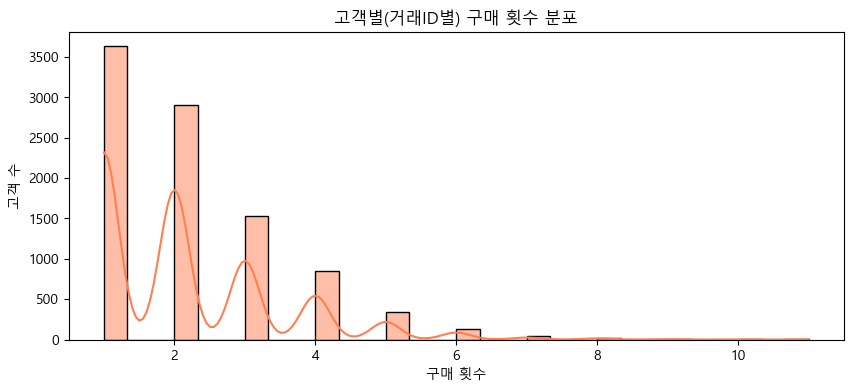

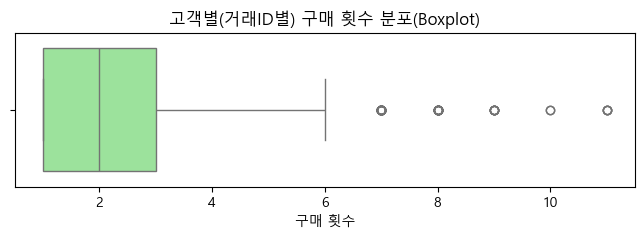

평균 구매 횟수: 2.1666138404648705
중앙값: 2.0
최대 구매 횟수: 11


In [30]:
# [7] Transaction ID별 구매 빈도수 분포 (고객별 구매 횟수 추정)
trans_counts = df['Transaction'].value_counts()

plt.figure(figsize=(10,4))
sns.histplot(trans_counts, bins=30, kde=True, color='coral')
plt.title('고객별(거래ID별) 구매 횟수 분포')
plt.xlabel('구매 횟수')
plt.ylabel('고객 수')
plt.show()

plt.figure(figsize=(8,2))
sns.boxplot(x=trans_counts, color='lightgreen')
plt.title('고객별(거래ID별) 구매 횟수 분포(Boxplot)')
plt.xlabel('구매 횟수')
plt.show()

print('평균 구매 횟수:', trans_counts.mean())
print('중앙값:', trans_counts.median())
print('최대 구매 횟수:', trans_counts.max())

1. 데이터 기본 특성

- 총 20,507건의 거래 데이터, 94종의 제품, 159일간의 기록이 포함되어 있음
- 가장 많이 팔린 제품은 Coffee로 5,471건의 판매를 기록하였으며, Bread, Tea, Cake 등이 그 뒤를 이음
- 거래는 주로 오후 시간대, 주중 및 토요일에 집중되는 경향이 확인됨
- 거래량이 가장 많았던 날짜는 2017-02-04로 총 292건의 거래가 발생함
- 시간대 기준으로는 11시에 가장 많은 거래가 발생하였고, 요일 기준으로는 토요일이 가장 활발했음 (4,605건)

2. 시계열 및 패턴 분석

- 월별 거래 건수는 11~12월, 2~3월에 많았으며, 10월과 4월은 데이터 수집 기간이 짧아 거래량이 낮게 나타남
- 상위 10개 제품이 전체 판매의 73% 이상을 차지하였으며, 이 중 Coffee 하나만으로도 전체의 26.7%를 차지함
- 주요 품목인 Coffee와 Bread는 오전 9시부터 11시, 특히 토요일에 판매가 집중됨
- 시간대별로는 오전부터 점심 무렵(9~15시)에 거래가 집중되고, 오후 이후에는 급격히 감소하는 경향이 있음
- 요일별로는 주말, 특히 토요일에 판매가 급증하며, 평일은 월~목 유사한 수준, 금요일부터 거래가 증가하는 흐름

3. 고객(거래ID)별 분석

- 전체 고객 중 한 번만 방문한 고객의 비중이 가장 높았으며, 2~3회 반복 구매 고객도 다수 존재함
- 평균 구매 횟수는 2.1회, 중앙값은 2회였으며, 최대 11회까지 반복 구매한 고객도 있음
- 일부 단골 고객이 전체 매출에 의미 있는 기여를 하고 있는 구조로 파악됨

4. 데이터 품질

- 결측치, 중복치, 이상치가 거의 없어 데이터 품질이 매우 우수한 것으로 판단됨
- date_time 컬럼을 날짜, 시간, 요일, 시간대 등으로 분리하여 다양한 시계열 분석이 가능함

5. 시간대 및 요일별 구매 패턴

- 시간대별로는 afternoon(오후) 거래가 전체의 약 57%로 가장 많았고, morning(아침)이 약 40%로 뒤를 이음
- evening과 night 시간대의 거래는 매우 적었으며, 그래프에서도 뚜렷한 차이를 보임
- 시간별 분석에서는 9~15시 사이에 거래가 집중되었고, 11~13시가 피크타임으로 나타남
- 17시 이후부터 거래가 급격히 줄어들며, 20시 이후에는 거의 발생하지 않음
- 요일별로는 주중이 62%로 주말보다 많지만, 토요일 단일 요일의 거래량이 가장 많았음
- 월~목요일은 유사한 수준의 거래량을 보이며, 금요일부터 거래가 증가하고 일요일은 다시 감소하는 패턴을 보임

6. 제품별 판매 집중도

- 상위 10개 제품이 전체 판매의 73% 이상을 차지함
- Coffee(26.7%), Bread(16.2%), Tea(7.0%), Cake(5.0%) 순으로 판매량이 높았으며, 나머지 84개 제품의 비중은 26.8%에 불과함
- 소수 인기 품목에 매출이 집중된 구조로, 비인기 제품에 대한 마케팅 전략이 필요함

7. 인기 품목별 시간 및 요일 패턴

- Coffee는 오전 9~11시, 토요일에 집중적으로 판매됨. 평일보다 주말 판매량이 높음
- Bread 역시 유사한 시간대 및 요일에 판매 집중이 나타남
- 두 품목 모두 오후 3시 이후에는 판매량이 급감하며, 시계열 곡선상 뚜렷한 종 모양을 나타냄
- 요일별 그래프에서도 토요일 판매량이 압도적으로 높음

8. 고객별 구매 특성

- 전체 고객 중 단 1회의 거래만 진행한 고객이 가장 많으며, 2~3회 반복 고객도 일정 비율 존재함
- 평균 2.1회, 중앙값 2회, 최대 11회까지 반복 구매한 고객이 존재함
- 박스플롯 분석에서 4회 이상 반복 구매 고객은 극소수로 확인되어, 핵심 단골 고객군으로 구분 가능함
- 해당 고객군을 대상으로 한 리워드, 쿠폰 발행 등의 전략이 효과적일 것으로 판단됨

9. 종합 인사이트

- 거래가 오전~점심, 토요일, 인기 품목에 집중되어 있어, 이 시간대 및 요일에 타겟 마케팅, 세트 메뉴, 주말 프로모션 등을 강화할 필요가 있음
- 상위 품목 집중도가 높아, 신제품 또는 비인기 품목의 교차판매, 번들링, 시식 이벤트 등 판촉 전략이 요구됨
- 고객 세분화를 기반으로 한 맞춤 전략 수립이 필요하며, 특히 단골 고객 대상 리워드 프로그램은 고객 유지에 효과적일 것으로 기대됨
- 운영 시간과 인력 배치 측면에서도 9~15시, 토요일에 집중하는 방식이 효율적일 것임


## 4. 장바구니 분석

## 4. 장바구니 분석 (연관규칙/순차패턴 마이닝)

이 파트에서는 베이커리 거래 데이터를 활용해 다음을 수행합니다.

- **연관규칙 마이닝**: Apriori, FP-Growth 알고리즘으로 자주 함께 구매되는 상품 조합 및 연관규칙 도출
- **순차 패턴 마이닝**: PrefixSpan 알고리즘으로 구매 순서가 중요한 패턴(예: 먼저 빵, 그다음 커피 등) 탐색

분석 순서:
1. 데이터 전처리 (거래별 상품 리스트화)
2. 연관규칙 마이닝 (Apriori, FP-Growth)
3. 순차 패턴 마이닝 (PrefixSpan)
4. 결과 해석 및 시각화